# Lab 02 : Policy Network with Local Rewards (REINFORCE) - demo

This notebook demonstrates the implementation of the REINFORCE algorithm, a policy gradient method, to solve the CartPole-v0 environment from OpenAI Gym. It uses a neural network to directly learn a stochastic policy that maps environment states to action probabilities.

Policy Network: Defines a Policy_NN class with a hidden layer (256 units) that uses a softmax activation to output probabilities for selecting left or right actions.

Trajectory Rollouts: Implements a Rollout_Episodes class to collect batches of experiences, including rewards and log probabilities, by interacting with the environment.

Reward Processing: Calculates discounted cumulative rewards and applies z-score normalization to stabilize training.

Optimization: Uses the Adam optimizer to update network weights by minimizing a loss function derived from the policy gradient theorem.

Performance Tracking: Includes a training loop that visualizes progress, showing the model reaching the balance threshold (approximately 400 steps) after around 300 epochs.


In [ ]:
# For Google Colaboratory
import sys, os
if 'google.colab' in sys.modules:
    !pip install 'gymnasium[classic_control]' 
    !pip install gym-notebook-wrapper
    

In [1]:
import torch
import torch.nn as nn
torch.manual_seed(torch.randint(10000,())) # random seed for pythorch random generator
import time
import numpy as np
import os
import pickle
import gymnasium as gym 
import matplotlib
import matplotlib.pyplot as plt
from IPython import display
from collections import namedtuple
import random
from itertools import count


# Dataset

In [39]:
#Initialize the environment with the same seed/initialization value
env = gym.make('CartPole-v1')

# Reset the environment
state, info = env.reset() # initial state from the environment
print('init state:',state)

# Rollout one episode until it finishes 
for t in count():  
    action = torch.LongTensor(1).random_(0,2).item() # randomly generated action=a in {0,1}
    state, reward, terminated, truncated, info = env.step(action) # receive next state=s' and reward=r
    done = terminated or truncated
    print('t=',t, 'action=',action, 'state=',np.array_str(state, precision=5), 'reward=',reward, 'done=',done )
    if done:
        break


init state: [0.02988745 0.00964328 0.00560988 0.00722813]
t= 0 action= 1 state= [ 0.03008  0.20468  0.00575 -0.28368] reward= 1.0 done= False
t= 1 action= 1 state= [ 3.41740e-02  3.99724e-01  8.08481e-05 -5.74542e-01] reward= 1.0 done= False
t= 2 action= 1 state= [ 0.04217  0.59484 -0.01141 -0.8672 ] reward= 1.0 done= False
t= 3 action= 1 state= [ 0.05407  0.79012 -0.02875 -1.16345] reward= 1.0 done= False
t= 4 action= 1 state= [ 0.06987  0.9856  -0.05202 -1.46501] reward= 1.0 done= False
t= 5 action= 0 state= [ 0.08958  0.79116 -0.08132 -1.18902] reward= 1.0 done= False
t= 6 action= 1 state= [ 0.1054   0.98723 -0.1051  -1.50604] reward= 1.0 done= False
t= 7 action= 1 state= [ 0.12515  1.18346 -0.13522 -1.8296 ] reward= 1.0 done= False
t= 8 action= 1 state= [ 0.14882  1.3798  -0.17182 -2.16105] reward= 1.0 done= False
t= 9 action= 0 state= [ 0.17641  1.18673 -0.21504 -1.92598] reward= 1.0 done= True


# Define the policy network

In [40]:
# class of policy network
class Policy_NN(nn.Module): 
    def __init__(self, net_parameters):
        super(Policy_NN, self).__init__()
        input_dim = net_parameters['input_dim']
        hidden_dim = net_parameters['hidden_dim']
        output_dim = net_parameters['output_dim']
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        actions_score = self.fc2(x)
        actions_prob = torch.softmax(actions_score, dim=1)
        return actions_prob
    
    def select_action(self, state): # select action w/ policy network
        probs = self.forward(state) # probability of action a in state s
        bernoulli_sampling = torch.distributions.Categorical(probs) 
        action = bernoulli_sampling.sample() # sample action a with Bernoulli sampling
        log_prob = bernoulli_sampling.log_prob(action) # compute log prob of selected action
        action = action.item()
        return action, log_prob

    def loss(self, batch_rewards, batch_log_probs):
        nb_episodes_per_batch = len(batch_rewards)
        batch_policy_losses = []
        gamma = opt_parameters['gamma']
        for episode in range(nb_episodes_per_batch):
            episode_rewards = batch_rewards[episode]
            episode_log_probs = batch_log_probs[episode]
            R = 0; policy_loss = []; rewards = []
            for r in episode_rewards[::-1]: # compute the discarded award at each time step
                R = r + gamma * R
                rewards.insert(0, R)
            episode_rewards = torch.tensor(rewards)
            episode_log_probs = torch.stack(episode_log_probs)
            episode_rewards = (episode_rewards - episode_rewards.mean()) \
                / (episode_rewards.std() + 1e-16) # z-score the rewards
            for log_prob, reward in zip(episode_log_probs, episode_rewards):
                policy_loss.append( -log_prob * reward )
            policy_loss = torch.cat(policy_loss).sum()
            batch_policy_losses.append(policy_loss)
        loss = torch.stack(batch_policy_losses).mean()
        return loss
        

        
# # class of rollout episodes
# class Rollout_Episodes():
    
#     def __init__(self,):
#         super(Rollout_Episodes, self).__init__()
    
def rollout_batch_episodes(env, opt_parameters, policy_net):
    # storage structure of all episodes (w/ different lengths):
    #   batch_rewards =         [ [- - -] , [- - - -] , ... , [- -] ]
    #   batch_log_probs =       [ [- - -] , [- - - -] , ... , [- -] ]
    #   batch_episode_lengths = [    - ,       -      , ...,    -   ]
    nb_episodes_per_batch = opt_parameters['nb_episodes_per_batch']
    env_seeds = opt_parameters['env_seed']
    batch_rewards = []
    batch_log_probs = []
    batch_episode_lengths = []
    for episode in range(nb_episodes_per_batch):
        rewards = []
        log_probs = []
        state, info = env.reset(seed=int(env_seeds[episode].item()))  # start with random seed
        for t in range(1000): # rollout one episode 
            state_pytorch = torch.from_numpy(state).float().unsqueeze(0) # state=s
            action, log_prob = policy_net.select_action(state_pytorch) # select action=a from state=s
            state, reward, terminated, truncated, info = env.step(action) # receive next state=s' and reward=r
            done = terminated or truncated
            rewards.append(reward)
            log_probs.append(log_prob)
            if done:
                batch_episode_lengths.append(t)
                batch_rewards.append(rewards)
                batch_log_probs.append(log_probs)
                break
    return batch_rewards, batch_log_probs, batch_episode_lengths

        
    
# network parameters
net_parameters = {}
net_parameters['input_dim'] = 4
net_parameters['hidden_dim'] = 128
net_parameters['output_dim'] = 2

# instantiate network
policy_net = Policy_NN(net_parameters)
print(policy_net)

# # instantiate rollout
# rollout_policy_net = Rollout_Episodes()

# optimization parameters
opt_parameters = {}
opt_parameters['nb_episodes_per_batch'] = 3
opt_parameters['env_seed'] = torch.LongTensor(opt_parameters['nb_episodes_per_batch']).random_(1,10000)

env = gym.make('CartPole-v1')

batch_rewards, batch_log_probs, batch_episode_lengths = rollout_batch_episodes(env, opt_parameters, policy_net)
#print('batch_rewards:',batch_rewards)
#print('batch_log_probs:',batch_log_probs)
print('batch_episode_lengths:',batch_episode_lengths)


Policy_NN(
  (fc1): Linear(in_features=4, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=2, bias=True)
)
batch_episode_lengths: [14, 20, 10]


# Test forward pass

In [41]:
# optimization parameters
opt_parameters = {}
opt_parameters['lr'] = 0.001
opt_parameters['nb_episodes_per_batch'] = 3
opt_parameters['nb_batches_per_epoch'] = 10
opt_parameters['env_seed'] = torch.LongTensor(opt_parameters['nb_episodes_per_batch']).random_(1,10000)
opt_parameters['gamma'] = 0.99

batch_rewards, batch_log_probs, batch_episode_lengths = rollout_batch_episodes(env, opt_parameters, policy_net)
#print('batch_rewards:',batch_rewards)
#print('batch_log_probs:',batch_log_probs)
print('batch_episode_lengths:',batch_episode_lengths)


batch_episode_lengths: [37, 10, 9]


# Test backward pass

In [42]:
# Loss
loss = policy_net.loss(batch_rewards, batch_log_probs)
print('loss:',loss)

# Backward pass
lr = opt_parameters['lr']
optimizer = torch.optim.Adam(policy_net.parameters(), lr=lr)
optimizer.zero_grad()
loss.backward()
optimizer.step()


loss: tensor(-0.0866, grad_fn=<MeanBackward0>)


# Train one epoch

In [43]:

def train_one_epoch(env, policy_net, opt_parameters):
    """
    train one epoch
    """
    policy_net.train()
    # rollout_policy_net = Rollout_Episodes()
    epoch_loss = 0
    nb_data = 0
    epoch_episode_length = 0
    epoch_episode_lengths = []
    nb_batches_per_epoch = opt_parameters['nb_batches_per_epoch']
    for iter in range(nb_batches_per_epoch):
        batch_rewards, batch_log_probs, batch_episode_lengths = rollout_batch_episodes(env, opt_parameters, policy_net)
        loss = policy_net.loss(batch_rewards, batch_log_probs)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_loss += loss.detach().item()
        nb_data += len(batch_episode_lengths)
        epoch_episode_length += torch.tensor(batch_episode_lengths).float().sum()
        epoch_episode_lengths.append(epoch_episode_length)
    epoch_loss /= nb_data
    epoch_episode_length /= nb_data
    return epoch_loss, epoch_episode_length, epoch_episode_lengths



# Train NN

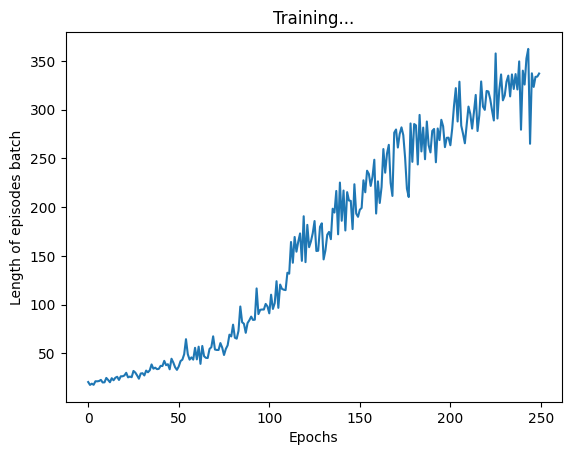

In [49]:
# network parameters
net_parameters = {}
net_parameters['input_dim'] = 4
net_parameters['hidden_dim'] = 256
net_parameters['output_dim'] = 2

# instantiate network
policy_net = Policy_NN(net_parameters)
print(policy_net)

# optimization parameters
opt_parameters = {}
opt_parameters['lr'] = 0.0005
opt_parameters['nb_episodes_per_batch'] = 25 
opt_parameters['nb_batches_per_epoch'] = 1
opt_parameters['env_seed'] = torch.LongTensor(opt_parameters['nb_episodes_per_batch']).random_(1,10000)
opt_parameters['gamma'] = 0.99

optimizer = torch.optim.Adam(policy_net.parameters(), lr=opt_parameters['lr'] )

# select maximum episode length to learn
env = gym.make('CartPole-v1')
env._max_episode_steps = 400 # 200 400
env.spec.reward_threshold = 0.975* env._max_episode_steps
print('env._max_episode_steps',env._max_episode_steps)

# train loop
all_epoch_lengths = []
start = time.time()
num_epochs = 250
for epoch in range(num_epochs): 
    
    # train one epoch
    epoch_train_loss, epoch_episode_length, epoch_episode_lengths = train_one_epoch(env, policy_net, opt_parameters)
 
    # stop training when reward is high
    if epoch_episode_length > env.spec.reward_threshold:
        print('Training done.')
        print("Last episode length is {}, epoch is {}".
              format(epoch_episode_length, epoch))
        break

    # print intermediate info
    if not epoch%1:
        print('Epoch: {}, time: {:.4f}, train_loss: {:.4f}, episode_length: {:.4f}'.format(epoch, time.time()-start, epoch_train_loss, epoch_episode_length))
        
    # plot all epochs
    all_epoch_lengths.append(epoch_episode_length)
    if not (epoch+1)%10:
        if epoch<num_epochs:
            display.clear_output(wait=True)
        plt.figure(2)
        plt.title('Training...')
        plt.xlabel('Epochs')
        plt.ylabel('Length of episodes batch')
        plt.plot(torch.Tensor(all_epoch_lengths).numpy())
        plt.pause(0.001)


# Visualize

Finished at step 308


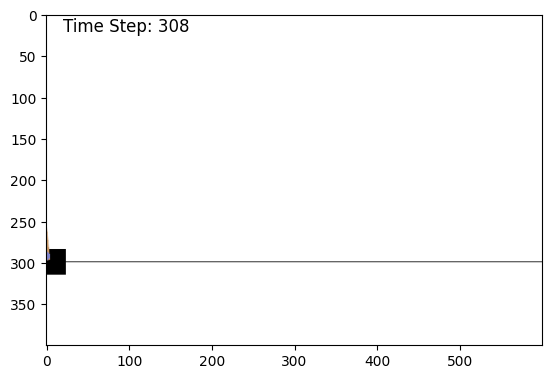

In [50]:
# For Google Colaboratory
import sys
if 'google.colab' in sys.modules:
    import gnwrapper
    env = gnwrapper.Monitor(gym.make('CartPole-v1', render_mode="rgb_array"), directory="./") 
    env._max_episode_steps = 5000
    # env._max_episode_steps = 100 # DEBUG
    state, _ = env.reset()
    for t in range(env._max_episode_steps):
        state_pytorch = torch.from_numpy(state).float().unsqueeze(0)
        action, _ = policy_net.eval().select_action(state_pytorch) # select action=a from state=s
        next_state, reward, terminated, truncated, info = env.step(action) # receive next state=s' and reward=r
        done = terminated or truncated
        # env.render() # no need this line with Monitor/gnwrapper; it records automatically
        if done:
            print(f"Episode finished at step {t}")
            break
    env.display()

# For Local Environment
else: 
    env = gym.make('CartPole-v1', render_mode="rgb_array")
    env._max_episode_steps = 5000
    # env._max_episode_steps = 100 # DEBUG
    state, info = env.reset() 
    img = plt.imshow(env.render()) # Setup the plot
    time_text = plt.text(20, 20, '', color='black', fontsize=12)
    for t in range(env._max_episode_steps):
        state_pytorch = torch.from_numpy(state).float().unsqueeze(0)
        action, _ = policy_net.eval().select_action(state_pytorch) # select action=a from state=s
        state, reward, terminated, truncated, info = env.step(action) # receive next state=s' and reward=r
        done = terminated or truncated
        img.set_data(env.render()) 
        time_text.set_text(f'Time Step: {t}')
        display.display(plt.gcf())
        display.clear_output(wait=True)
        if done:
            break
        env.close()
    print(f"Finished at step {t}")

        